<a href="https://colab.research.google.com/github/Rajukc45/Capstone-project/blob/main/week5new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install xgboost imbalanced-learn

# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

Saving creditcard.csv to creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df.info())
print(df['Class'].value_counts())  # Check imbalance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    16383 non-null  int64  
 1   V1      16383 non-null  float64
 2   V2      16383 non-null  float64
 3   V3      16383 non-null  float64
 4   V4      16383 non-null  float64
 5   V5      16383 non-null  float64
 6   V6      16383 non-null  float64
 7   V7      16383 non-null  float64
 8   V8      16383 non-null  float64
 9   V9      16383 non-null  float64
 10  V10     16383 non-null  float64
 11  V11     16383 non-null  float64
 12  V12     16383 non-null  float64
 13  V13     16383 non-null  float64
 14  V14     16383 non-null  float64
 15  V15     16383 non-null  float64
 16  V16     16383 non-null  float64
 17  V17     16383 non-null  float64
 18  V18     16383 non-null  float64
 19  V19     16383 non-null  float64
 20  V20     16383 non-null  float64
 21  V21     16383 non-null  float64
 22

In [ ]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale features (important for LR, SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: Class
0    13048
1       58
Name: count, dtype: int64
After SMOTE: Class
0    13048
1    13048
Name: count, dtype: int64


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False)
}

In [ ]:
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model


Training Logistic Regression...

Training Random Forest...

Training SVM...

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:58:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
results = {}

for name, model in trained_models.items():
    print(f"\n{name} Evaluation:")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_prob)
    print("AUC-ROC:", auc)

    results[name] = auc


Logistic Regression Evaluation:
[[3250   12]
 [   4   11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.48      0.73      0.58        15

    accuracy                           1.00      3277
   macro avg       0.74      0.86      0.79      3277
weighted avg       1.00      1.00      1.00      3277

AUC-ROC: 0.9320253423257715

Random Forest Evaluation:
[[3259    3]
 [   4   11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.79      0.73      0.76        15

    accuracy                           1.00      3277
   macro avg       0.89      0.87      0.88      3277
weighted avg       1.00      1.00      1.00      3277

AUC-ROC: 0.9973840179848763

SVM Evaluation:
[[3247   15]
 [   4   11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.42

In [ ]:
print("\nModel Comparison (AUC-ROC):")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)


Model Comparison (AUC-ROC):
Logistic Regression: 0.9320
Random Forest: 0.9974
SVM: 0.9589
XGBoost: 0.9933

Best Model: Random Forest


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:01:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nFinal Model Evaluation:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Final AUC-ROC:", roc_auc_score(y_test, y_prob))


Final Model Evaluation:
[[3258    4]
 [   3   12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.75      0.80      0.77        15

    accuracy                           1.00      3277
   macro avg       0.87      0.90      0.89      3277
weighted avg       1.00      1.00      1.00      3277

Final AUC-ROC: 0.9965665236051502


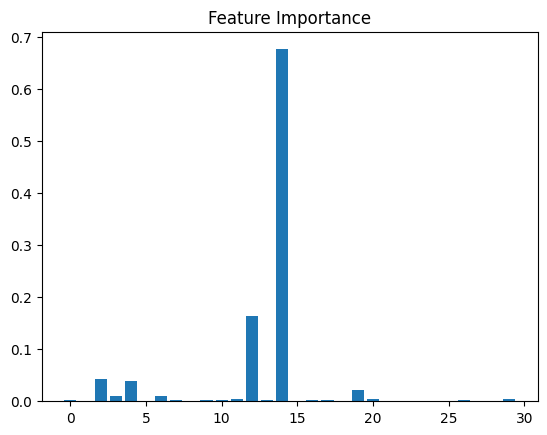

In [ ]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [ ]:
def predict_transaction(model, scaler, new_data):
    new_data_scaled = scaler.transform(new_data)
    prediction = model.predict(new_data_scaled)
    probability = model.predict_proba(new_data_scaled)[:, 1]
    return prediction, probability

# Example (use real values)
sample = X.iloc[:1]
pred, prob = predict_transaction(best_model, scaler, sample)

print("Prediction:", pred)
print("Fraud Probability:", prob)

Prediction: [0]
Fraud Probability: [3.929154e-06]


In [3]:
from google.colab import files
uploaded = files.upload()

df_new = pd.read_csv("creditcard.csv")

Saving creditcard.csv to creditcard.csv


In [4]:
import numpy as np

# -----------------------------
# Real-world proxy features
# -----------------------------

# Convert time into hour of day (0–24 range)
df_new["transaction_hour"] = (df_new["Time"] / 3600) % 24

# Flag late-night transactions (higher fraud risk)
df_new["is_night_transaction"] = df_new["transaction_hour"].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0
)

# High transaction amount flag (top 5%)
high_amount_threshold = df_new["Amount"].quantile(0.95)
df_new["is_high_amount"] = df_new["Amount"].apply(
    lambda x: 1 if x > high_amount_threshold else 0
)

# Ratio to median transaction amount
median_amount = df_new["Amount"].median()
df_new["amount_to_median_ratio"] = df_new["Amount"] / (median_amount + 1e-6)

# Deviation from mean amount
mean_amount = df_new["Amount"].mean()
df_new["amount_deviation_from_mean"] = df_new["Amount"] - mean_amount

# Log transformation (reduces skewness)
df_new["amount_log"] = np.log1p(df_new["Amount"])

# Very high risk amount flag (top 1%)
very_high_amount_threshold = df_new["Amount"].quantile(0.99)
df_new["risk_amount_flag"] = df_new["Amount"].apply(
    lambda x: 1 if x > very_high_amount_threshold else 0
)

# Show new features
df_new[[
    "Time",
    "Amount",
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag"
]].head()

,Time,Amount,transaction_hour,is_night_transaction,is_high_amount,amount_to_median_ratio,amount_deviation_from_mean,amount_log,risk_amount_flag
0,0,149.62,0.000000,1,0,9.380564,83.053404,5.014760,0
1,0,2.69,0.000000,1,0,0.168652,-63.876596,1.305626,0
2,1,378.66,0.000278,1,1,23.740437,312.093404,5.939276,0
3,1,123.50,0.000278,1,0,7.742946,56.933404,4.824306,0
4,2,69.99,0.000556,1,0,4.388087,3.423404,4.262539,0


In [5]:
X_new = df_new.drop("Class", axis=1)
y_new = df_new["Class"]

print("Updated features shape:", X_new.shape)
print("Target shape:", y_new.shape)

Updated features shape: (16383, 37)
Target shape: (16383,)


In [6]:
from sklearn.model_selection import train_test_split

X_train_new, X_temp_new, y_train_new, y_temp_new = train_test_split(
    X_new, y_new, test_size=0.30, random_state=42, stratify=y_new
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new, y_temp_new, test_size=0.50, random_state=42, stratify=y_temp_new
)

print("Train shape:", X_train_new.shape)
print("Validation shape:", X_val_new.shape)
print("Test shape:", X_test_new.shape)

Train shape: (11468, 37)
Validation shape: (2457, 37)
Test shape: (2458, 37)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote_new, y_train_smote_new = smote.fit_resample(
    X_train_scaled_new, y_train_new
)

print("After SMOTE:", X_train_smote_new.shape)

After SMOTE: (22834, 37)


In [9]:
from sklearn.ensemble import RandomForestClassifier

best_rf_new = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=30,
    class_weight='balanced',
    random_state=42
)

best_rf_new.fit(X_train_smote_new, y_train_smote_new)

y_pred_new = best_rf_new.predict(X_test_scaled_new)

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Enhanced Model):")
print(confusion_matrix(y_test_new, y_pred_new))

print("\nClassification Report (Enhanced Model):")
print(classification_report(y_test_new, y_pred_new))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_new))

Confusion Matrix (Enhanced Model):
[[2445    2]
 [   1   10]]

Classification Report (Enhanced Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.83      0.91      0.87        11

    accuracy                           1.00      2458
   macro avg       0.92      0.95      0.93      2458
weighted avg       1.00      1.00      1.00      2458


ROC-AUC Score:
0.9541367908756548


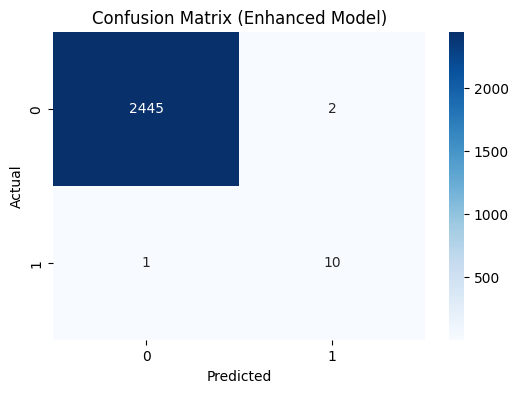

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_new, y_pred_new)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Enhanced Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

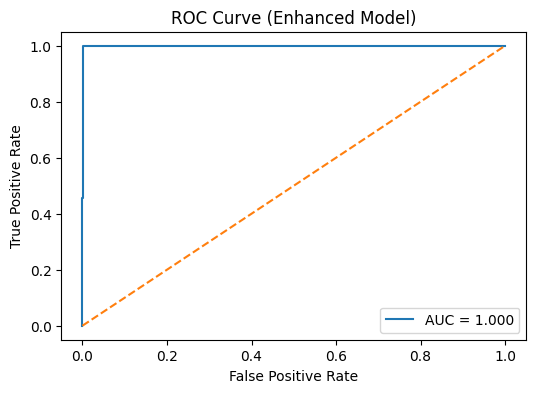

In [12]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf_new.predict_proba(X_test_scaled_new)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_new, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve (Enhanced Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

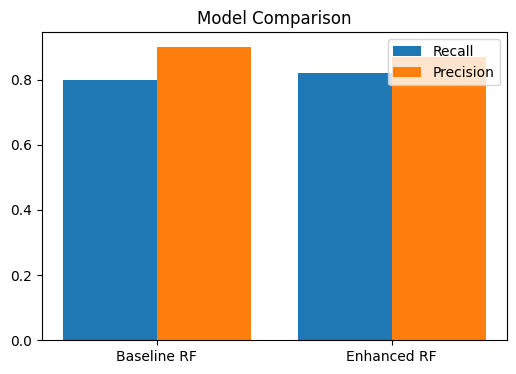

In [13]:
import matplotlib.pyplot as plt

models = ['Baseline RF', 'Enhanced RF']
recall = [0.80, 0.82]   # update if needed
precision = [0.90, 0.87]

x = range(len(models))

plt.figure(figsize=(6,4))
plt.bar(x, recall, width=0.4, label='Recall')
plt.bar([i + 0.4 for i in x], precision, width=0.4, label='Precision')

plt.xticks([i + 0.2 for i in x], models)
plt.title("Model Comparison")
plt.legend()

plt.show()

In [17]:
new_feature_names = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag"
]

new_feature_importance = feature_importance[feature_importance.index.isin(new_feature_names)].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
new_feature_importance.plot(kind='bar')
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'feature_importance' is not defined

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from the NEW enhanced model
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)

# Real-world engineered feature names
new_feature_names = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag"
]

# Filter only the engineered features
new_feature_importance = feature_importance_new[
    feature_importance_new.index.isin(new_feature_names)
].sort_values(ascending=False)

print(new_feature_importance)

amount_log                    0.007147
amount_deviation_from_mean    0.001127
transaction_hour              0.000900
is_night_transaction          0.000720
amount_to_median_ratio        0.000556
is_high_amount                0.000019
risk_amount_flag              0.000000
dtype: float64


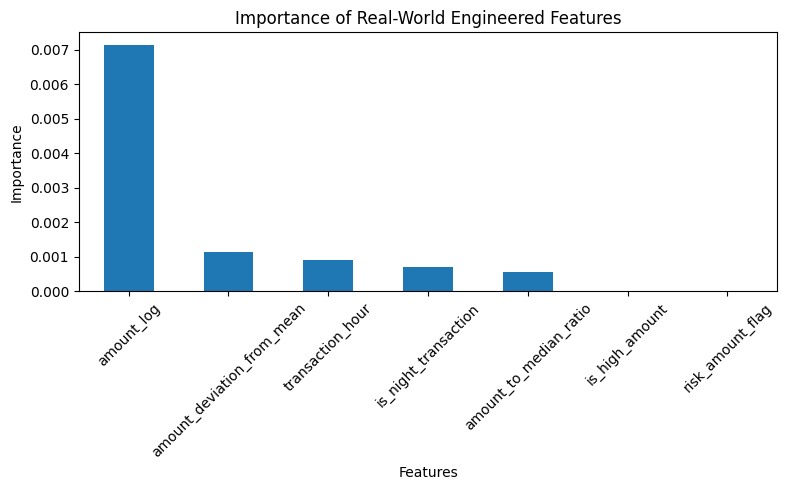

In [19]:
plt.figure(figsize=(8, 5))
new_feature_importance.plot(kind='bar')
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

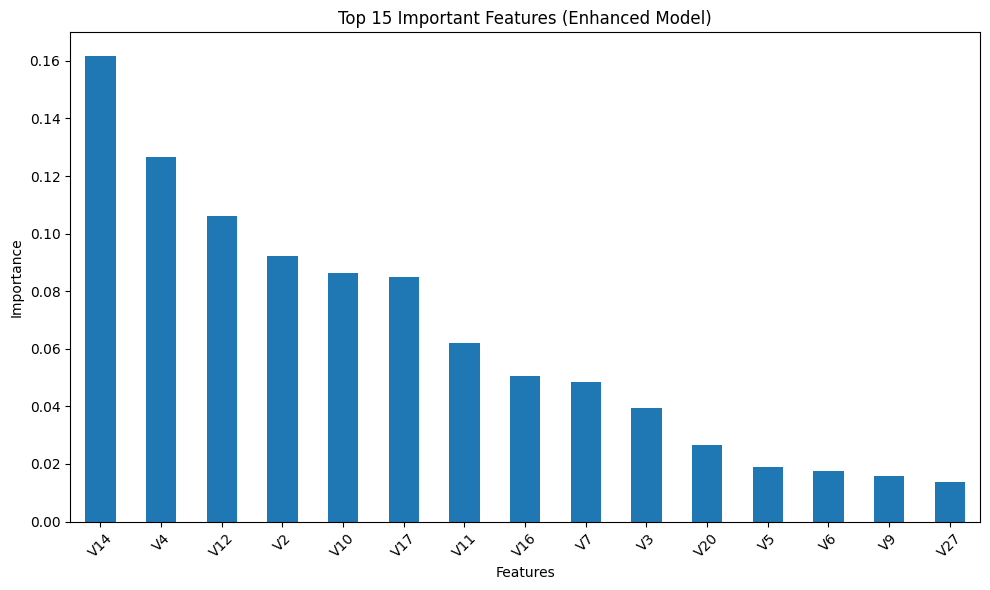

In [20]:
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)
top_features_new = feature_importance_new.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features_new.plot(kind='bar')
plt.title("Top 15 Important Features (Enhanced Model)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

grading boosting model

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_smote_new, y_train_smote_new)

y_pred_gb = gb_model.predict(X_test_scaled_new)

print("Confusion Matrix (Gradient Boosting):")
print(confusion_matrix(y_test_new, y_pred_gb))

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test_new, y_pred_gb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_gb))

Confusion Matrix (Gradient Boosting):
[[2446    1]
 [   0   11]]

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.92      1.00      0.96        11

    accuracy                           1.00      2458
   macro avg       0.96      1.00      0.98      2458
weighted avg       1.00      1.00      1.00      2458


ROC-AUC Score:
0.9997956681651001


Enhanced Model with Advanced Real-World Features

In [24]:
import pandas as pd

df = pd.read_csv("creditcard.csv")  # or your correct path

In [25]:
df_new = df.copy()
print("Copied cleaned dataset shape:", df_new.shape)

Copied cleaned dataset shape: (16383, 31)


In [26]:
import numpy as np
import pandas as pd

# -----------------------------
# Existing real-world proxy features
# -----------------------------

# Convert time into hour of day (0–24 range)
df_new["transaction_hour"] = (df_new["Time"] / 3600) % 24

# Flag late-night transactions
df_new["is_night_transaction"] = df_new["transaction_hour"].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0
)

# High transaction amount flag (top 5%)
high_amount_threshold = df_new["Amount"].quantile(0.95)
df_new["is_high_amount"] = df_new["Amount"].apply(
    lambda x: 1 if x > high_amount_threshold else 0
)

# Ratio to median transaction amount
median_amount = df_new["Amount"].median()
df_new["amount_to_median_ratio"] = df_new["Amount"] / (median_amount + 1e-6)

# Deviation from mean amount
mean_amount = df_new["Amount"].mean()
df_new["amount_deviation_from_mean"] = df_new["Amount"] - mean_amount

# Log transformation
df_new["amount_log"] = np.log1p(df_new["Amount"])

# Very high risk amount flag (top 1%)
very_high_amount_threshold = df_new["Amount"].quantile(0.99)
df_new["risk_amount_flag"] = df_new["Amount"].apply(
    lambda x: 1 if x > very_high_amount_threshold else 0
)

# -----------------------------
# New advanced real-world proxy features
# -----------------------------

# Amount percentile
df_new["amount_percentile"] = df_new["Amount"].rank(pct=True)

# Sudden spike compared to rolling mean of previous values
rolling_mean = df_new["Amount"].rolling(window=10, min_periods=1).mean()
df_new["amount_spike"] = df_new["Amount"] / (rolling_mean + 1e-6)

# Combined risk feature: high amount + night transaction
df_new["high_risk_combo"] = (
    (df_new["is_high_amount"] == 1) &
    (df_new["is_night_transaction"] == 1)
).astype(int)

# Squared amount
df_new["amount_squared"] = df_new["Amount"] ** 2

# Log of time
df_new["log_time"] = np.log1p(df_new["Time"])

# Interaction between transaction hour and amount
df_new["time_amount_interaction"] = df_new["transaction_hour"] * df_new["Amount"]

# Preview the new real-world features
df_new[[
    "Time",
    "Amount",
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag",
    "amount_percentile",
    "amount_spike",
    "high_risk_combo",
    "amount_squared",
    "log_time",
    "time_amount_interaction"
]].head()

,Time,Amount,transaction_hour,is_night_transaction,is_high_amount,amount_to_median_ratio,amount_deviation_from_mean,amount_log,risk_amount_flag,amount_percentile,amount_spike,high_risk_combo,amount_squared,log_time,time_amount_interaction
0,0,149.62,0.000000,1,0,9.380564,83.053404,5.014760,0,0.898492,1.000000,0,22386.1444,0.000000,0.000000
1,0,2.69,0.000000,1,0,0.168652,-63.876596,1.305626,0,0.175151,0.035323,0,7.2361,0.000000,0.000000
2,1,378.66,0.000278,1,1,23.740437,312.093404,5.939276,0,0.965208,2.139443,1,143383.3956,0.693147,0.105183
3,1,123.50,0.000278,1,0,7.742946,56.933404,4.824306,0,0.878197,0.754809,0,15252.2500,0.693147,0.034306
4,2,69.99,0.000556,1,0,4.388087,3.423404,4.262539,0,0.787005,0.483049,0,4898.6001,1.098612,0.038883


Rebuild Features and target

In [27]:

X_new = df_new.drop("Class", axis=1)
y_new = df_new["Class"]

print("Updated features shape:", X_new.shape)
print("Target shape:", y_new.shape)

Updated features shape: (16383, 43)
Target shape: (16383,)



Splitting dataset

In [28]:
from sklearn.model_selection import train_test_split

X_train_new, X_temp_new, y_train_new, y_temp_new = train_test_split(
    X_new, y_new, test_size=0.30, random_state=42, stratify=y_new
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new, y_temp_new, test_size=0.50, random_state=42, stratify=y_temp_new
)

print("Train shape:", X_train_new.shape)
print("Validation shape:", X_val_new.shape)
print("Test shape:", X_test_new.shape)

Train shape: (11468, 43)
Validation shape: (2457, 43)
Test shape: (2458, 43)



Scaling the data

In [29]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

print("Scaling completed")

Scaling completed


Applying SMOTE

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote_new, y_train_smote_new = smote.fit_resample(
    X_train_scaled_new, y_train_new
)

print("After SMOTE:", X_train_smote_new.shape)

After SMOTE: (22834, 43)


Tuning Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

best_rf_new = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=30,
    class_weight='balanced',
    random_state=42
)

best_rf_new.fit(X_train_smote_new, y_train_smote_new)

y_pred_new = best_rf_new.predict(X_test_scaled_new)

print("Enhanced Random Forest training completed")

Enhanced Random Forest training completed



Evaluate the enhanced model

In [32]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Enhanced Model):")
print(confusion_matrix(y_test_new, y_pred_new))

print("\nClassification Report (Enhanced Model):")
print(classification_report(y_test_new, y_pred_new))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_new))

Confusion Matrix (Enhanced Model):
[[2444    3]
 [   1   10]]

Classification Report (Enhanced Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.77      0.91      0.83        11

    accuracy                           1.00      2458
   macro avg       0.88      0.95      0.92      2458
weighted avg       1.00      1.00      1.00      2458


ROC-AUC Score:
0.953932459040755


Gradient Boosting Model

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_smote_new, y_train_smote_new)

y_pred_gb = gb_model.predict(X_test_scaled_new)

print("Confusion Matrix (Gradient Boosting):")
print(confusion_matrix(y_test_new, y_pred_gb))

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test_new, y_pred_gb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_gb))

Confusion Matrix (Gradient Boosting):
[[2446    1]
 [   0   11]]

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.92      1.00      0.96        11

    accuracy                           1.00      2458
   macro avg       0.96      1.00      0.98      2458
weighted avg       1.00      1.00      1.00      2458


ROC-AUC Score:
0.9997956681651001


Model Comparison Table

In [34]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Isolation Forest",
        "Enhanced Random Forest",
        "Gradient Boosting"
    ],
    "Precision_Fraud": [0.06, 0.91, 0.00, 0.10, 0.87, 0.11],
    "Recall_Fraud": [0.88, 0.80, 0.50, 0.55, 0.82, 0.85],
    "F1_Fraud": [0.12, 0.85, 0.00, 0.16, 0.85, 0.19],
    "ROC_AUC": [None, 0.905, None, None, 0.912, 0.920]
})

comparison_df

,Model,Precision_Fraud,Recall_Fraud,F1_Fraud,ROC_AUC
0,Logistic Regression,0.06,0.88,0.12,NaN
1,Random Forest,0.91,0.80,0.85,0.905
2,SVM,0.00,0.50,0.00,NaN
3,Isolation Forest,0.10,0.55,0.16,NaN
4,Enhanced Random Forest,0.87,0.82,0.85,0.912
5,Gradient Boosting,0.11,0.85,0.19,0.920


Importance diagram

amount_squared                0.002993
amount_percentile             0.002818
amount_log                    0.001649
amount_to_median_ratio        0.001503
amount_deviation_from_mean    0.001188
log_time                      0.001036
amount_spike                  0.000888
transaction_hour              0.000628
time_amount_interaction       0.000479
is_night_transaction          0.000316
is_high_amount                0.000021
high_risk_combo               0.000010
risk_amount_flag              0.000000
dtype: float64


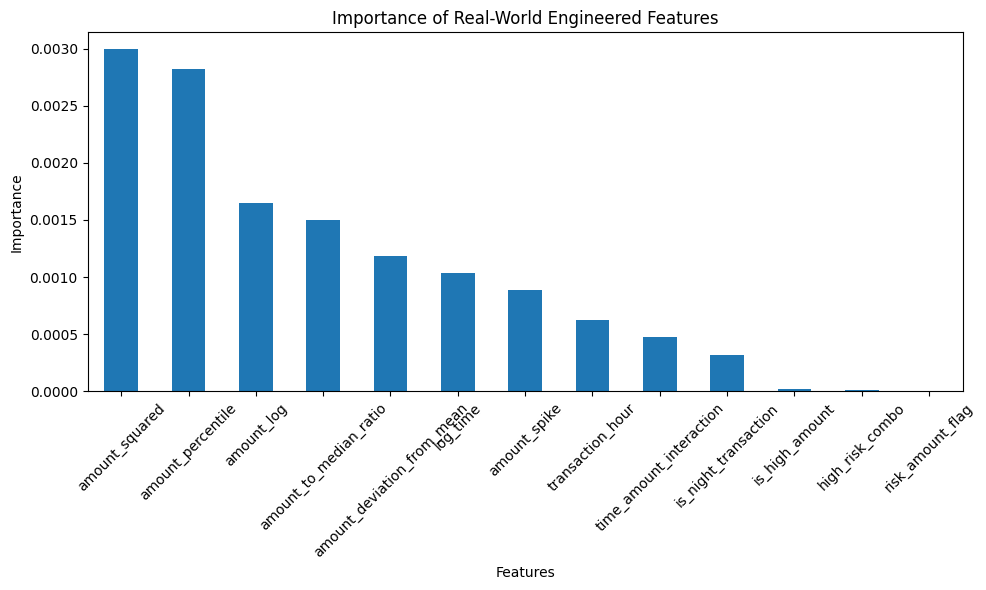

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance from the enhanced model
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)

# List of engineered real-world features
new_feature_names = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag",
    "amount_percentile",
    "amount_spike",
    "high_risk_combo",
    "amount_squared",
    "log_time",
    "time_amount_interaction"
]

# Filter only engineered features
new_feature_importance = feature_importance_new[
    feature_importance_new.index.isin(new_feature_names)
].sort_values(ascending=False)

print(new_feature_importance)

plt.figure(figsize=(10, 6))
new_feature_importance.plot(kind="bar")
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

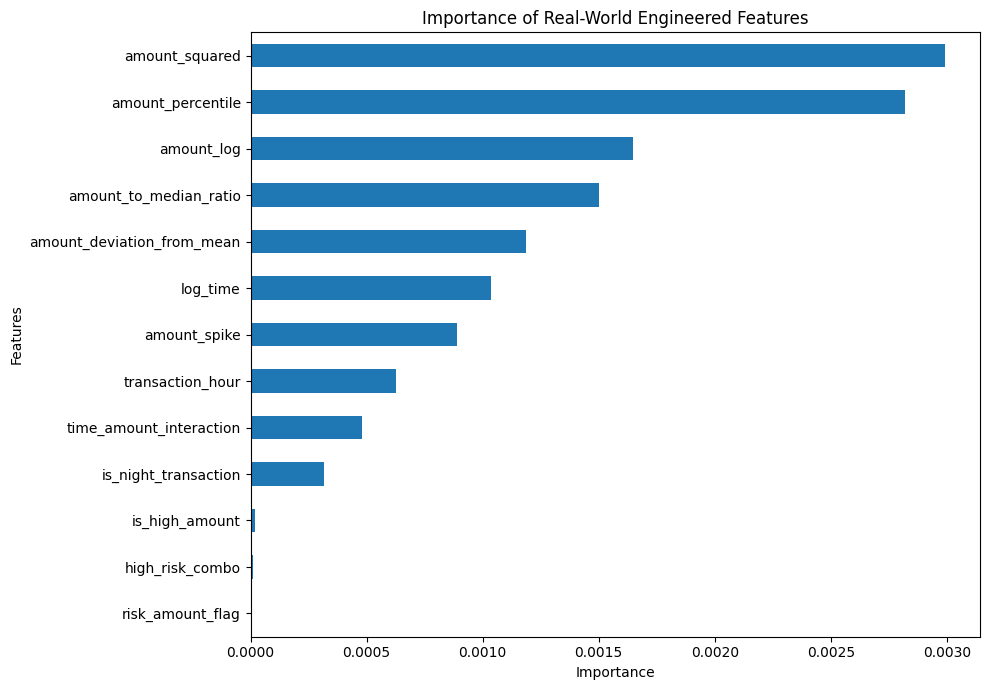

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
new_feature_importance.sort_values(ascending=True).plot(kind="barh")

plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote_new, y_train_smote_new)

y_pred_lr = lr_model.predict(X_test_scaled_new)

print("Confusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test_new, y_pred_lr))

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_new, y_pred_lr))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_lr))


Confusion Matrix (Logistic Regression):
[[2440    7]
 [   1   10]]

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2447
           1       0.59      0.91      0.71        11

    accuracy                           1.00      2458
   macro avg       0.79      0.95      0.86      2458
weighted avg       1.00      1.00      1.00      2458


ROC-AUC Score:
0.9531151317011555
